# Decision Tree Classification on UCI Seeds Dataset
## Complete Analysis: Tasks 1, 2, and 3

**Course Code** CS401

**Dataset:** UCI Seeds Dataset (Wheat Kernel Classification)  

**Name :** Vemula Srishanth Goud

**Student.id** 25251798

**Programme code** MHR64 - M.s Data science and analytics 


---

## Setup and Data Loading

In [9]:
# Import required libraries
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score)
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

In [10]:
# Seeds Dataset from UCI Machine Learning Repository
data_string = """area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coef,groove_length,variety
15.26,14.84,0.871,5.763,3.312,2.221,5.22,1
14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
14.29,14.09,0.905,5.291,3.337,2.699,4.825,1
13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1
14.69,14.49,0.8799,5.563,3.259,3.586,5.219,1
14.11,14.1,0.8911,5.42,3.302,2.7,5.0,1
16.63,15.46,0.8747,6.053,3.465,2.04,5.877,1
16.44,15.25,0.888,5.884,3.505,1.969,5.533,1
15.26,14.85,0.8696,5.714,3.242,4.543,5.314,1
14.03,14.16,0.8796,5.438,3.201,1.717,5.001,1
13.89,14.02,0.888,5.439,3.199,3.986,4.738,1
13.78,14.06,0.8759,5.479,3.156,3.136,4.872,1
13.74,14.05,0.8744,5.482,3.114,2.932,4.825,1
14.59,14.28,0.8993,5.351,3.333,4.185,4.781,1
13.99,13.83,0.9183,5.119,3.383,5.234,4.781,1
15.69,14.75,0.9058,5.527,3.514,1.599,5.046,1
14.7,14.21,0.9153,5.205,3.466,1.767,4.649,1
12.72,13.57,0.8686,5.226,3.049,4.102,4.914,1
14.16,14.4,0.8584,5.658,3.129,3.072,5.176,1
14.11,14.26,0.8722,5.52,3.168,2.688,5.219,1
15.88,14.9,0.8988,5.618,3.507,2.377,5.334,1
12.08,13.23,0.8664,5.099,2.936,1.415,4.961,1
15.01,14.76,0.8657,5.789,3.245,1.791,5.001,1
16.19,15.16,0.8849,5.833,3.421,0.903,5.307,1
13.02,13.76,0.8641,5.395,3.026,3.373,4.825,1
12.74,13.67,0.8564,5.395,2.956,2.504,4.869,1
14.11,14.18,0.882,5.541,3.221,2.754,5.038,1
13.45,14.02,0.8604,5.516,3.065,3.531,5.097,1
13.16,13.82,0.8662,5.454,2.975,3.56,5.009,1
15.49,14.94,0.8724,5.757,3.371,3.412,5.228,1
14.09,14.41,0.8544,5.658,3.074,3.527,5.137,1
13.94,14.17,0.8728,5.585,3.15,2.124,5.012,1
15.05,14.68,0.8782,5.712,3.314,2.932,5.316,1
16.12,15.0,0.9,5.709,3.485,2.27,5.443,1
16.2,15.27,0.8734,5.826,3.464,2.823,5.527,1
17.08,15.38,0.9079,5.832,3.683,2.956,5.484,1
14.8,14.52,0.8823,5.656,3.288,3.112,5.309,1
14.28,14.17,0.8944,5.397,3.298,6.685,5.001,1
13.54,13.85,0.8871,5.348,3.156,2.587,5.178,1
13.5,13.85,0.8852,5.351,3.158,2.249,5.176,1
13.16,13.55,0.9009,5.138,3.201,2.461,4.783,1
15.5,14.86,0.882,5.877,3.396,4.711,5.528,1
15.11,14.54,0.8986,5.579,3.462,3.128,5.18,1
13.8,14.04,0.8794,5.376,3.155,1.56,4.961,1
15.36,14.76,0.8861,5.701,3.393,1.367,5.132,1
14.99,14.56,0.8883,5.57,3.377,2.958,5.175,1
14.79,14.52,0.8819,5.545,3.291,2.704,5.111,1
14.86,14.67,0.8676,5.678,3.258,2.129,5.351,1
14.43,14.4,0.8751,5.585,3.272,3.975,5.144,1
15.78,14.91,0.8923,5.674,3.434,5.593,5.136,1
14.49,14.61,0.8538,5.715,3.113,4.116,5.396,1
14.33,14.28,0.8831,5.504,3.199,3.328,5.224,1
14.52,14.6,0.8557,5.741,3.113,1.481,5.487,1
15.03,14.77,0.8658,5.702,3.212,1.933,5.439,1
14.46,14.35,0.8818,5.388,3.377,2.802,5.044,1
14.92,14.43,0.9006,5.384,3.412,1.142,5.088,1
15.38,14.66,0.8997,5.618,3.37,2.346,5.092,1
12.11,13.47,0.8392,5.159,3.032,1.502,4.519,1
11.42,12.86,0.8683,5.008,2.85,2.7,4.607,1
11.23,12.63,0.884,4.902,2.879,2.269,4.703,1
12.36,13.19,0.8923,5.076,3.042,3.22,4.605,1
13.22,13.84,0.868,5.395,3.07,4.157,5.088,1
12.78,13.57,0.8716,5.262,3.026,1.176,4.782,1
12.88,13.5,0.8879,5.139,3.119,2.352,4.607,1
14.34,14.37,0.8726,5.63,3.19,1.313,5.15,1
14.01,14.29,0.8625,5.609,3.158,2.217,5.132,1
14.37,14.39,0.8726,5.569,3.153,1.464,5.3,1
12.73,13.75,0.8458,5.412,2.882,3.533,5.067,1
17.63,15.98,0.8673,6.191,3.561,4.076,6.06,2
14.38,14.58,0.8512,5.775,3.128,3.685,5.412,2
16.84,15.67,0.8623,5.998,3.484,4.675,5.877,2
17.26,15.73,0.8763,5.978,3.594,4.539,5.791,2
19.11,16.26,0.9081,6.154,3.93,2.936,6.079,2
16.82,15.51,0.8786,6.017,3.486,4.004,5.841,2
16.77,15.62,0.8638,5.927,3.438,4.92,5.795,2
17.32,15.91,0.8599,6.064,3.403,3.824,5.922,2
20.71,17.23,0.8763,6.579,3.814,4.451,6.451,2
18.94,16.49,0.875,6.445,3.639,5.064,6.099,2
17.12,15.55,0.8892,5.85,3.566,2.858,5.746,2
16.53,15.34,0.8823,5.875,3.467,5.532,5.88,2
18.72,16.19,0.8977,6.006,3.857,5.324,5.879,2
20.2,16.89,0.8894,6.285,3.864,5.173,6.187,2
19.57,16.74,0.8779,6.384,3.772,1.472,6.273,2
19.51,16.71,0.878,6.366,3.801,2.962,6.315,2
18.27,16.09,0.887,6.173,3.651,2.443,6.197,2
18.88,16.26,0.8969,6.084,3.764,1.649,6.109,2
18.98,16.66,0.859,6.549,3.67,3.691,6.498,2
21.18,17.21,0.8989,6.573,4.033,5.78,6.231,2
20.88,17.05,0.9031,6.45,4.032,5.016,6.321,2
20.1,16.99,0.8746,6.581,3.785,1.955,6.449,2
18.76,16.2,0.8984,6.172,3.796,3.12,6.053,2
18.81,16.29,0.8906,6.272,3.693,3.237,6.053,2
18.59,16.05,0.9066,6.037,3.86,6.001,5.877,2
18.36,16.52,0.8452,6.666,3.485,4.933,6.448,2
16.87,15.65,0.8648,6.139,3.463,3.696,5.967,2
19.31,16.59,0.8815,6.341,3.81,3.477,6.238,2
18.98,16.57,0.8687,6.449,3.552,2.144,6.453,2
18.17,16.26,0.8637,6.271,3.512,2.853,6.273,2
18.72,16.34,0.881,6.219,3.684,2.188,6.097,2
16.41,15.25,0.8866,5.718,3.525,4.217,5.618,2
17.99,15.86,0.8992,5.89,3.694,2.068,5.837,2
19.46,16.5,0.8985,6.113,3.892,4.308,6.009,2
19.18,16.63,0.8717,6.369,3.681,3.357,6.229,2
18.95,16.42,0.8829,6.248,3.755,3.368,6.148,2
18.83,16.29,0.8917,6.037,3.786,2.553,5.879,2
18.85,16.17,0.9056,6.152,3.806,2.843,6.2,2
17.63,15.86,0.88,6.033,3.573,3.747,5.929,2
19.94,16.92,0.8752,6.675,3.763,3.252,6.55,2
18.55,16.22,0.8865,6.153,3.674,1.738,5.894,2
18.45,16.12,0.8921,6.107,3.769,2.235,5.794,2
19.38,16.72,0.8716,6.303,3.791,3.678,5.965,2
19.13,16.31,0.9035,6.183,3.902,2.109,5.924,2
19.14,16.61,0.8722,6.259,3.737,6.682,6.053,2
20.97,17.25,0.8859,6.563,3.991,4.677,6.316,2
19.06,16.45,0.8854,6.416,3.719,2.248,6.163,2
18.96,16.2,0.9077,6.051,3.897,4.334,5.75,2
19.15,16.45,0.889,6.245,3.815,3.084,6.185,2
18.89,16.23,0.9008,6.227,3.769,3.639,5.966,2
20.03,16.9,0.8811,6.493,3.857,3.063,6.32,2
20.24,16.91,0.8897,6.315,3.962,5.901,6.188,2
18.14,16.12,0.8772,6.059,3.563,3.619,6.011,2
16.17,15.38,0.8588,5.762,3.387,4.286,5.703,2
18.43,15.97,0.9077,5.98,3.771,2.984,5.905,2
15.99,14.89,0.9064,5.363,3.582,3.336,5.144,2
18.75,16.18,0.8999,6.111,3.869,4.188,5.992,2
18.65,16.41,0.8698,6.285,3.594,4.391,6.102,2
17.98,15.85,0.8993,5.979,3.687,2.257,5.919,2
20.16,17.03,0.8735,6.513,3.773,1.91,6.185,2
17.55,15.66,0.8991,5.791,3.69,5.366,5.661,2
18.3,15.89,0.9108,5.979,3.755,2.837,5.962,2
18.94,16.32,0.8942,6.144,3.825,2.908,5.949,2
15.38,14.9,0.8706,5.884,3.268,4.462,5.795,2
16.16,15.33,0.8644,5.845,3.395,4.266,5.795,2
15.56,14.89,0.8823,5.776,3.408,4.972,5.847,2
15.38,14.66,0.899,5.477,3.465,3.6,5.439,2
17.36,15.76,0.8785,6.145,3.574,3.526,5.971,2
15.57,15.15,0.8527,5.92,3.231,2.64,5.879,2
15.6,15.11,0.858,5.832,3.286,2.725,5.752,2
16.23,15.18,0.885,5.872,3.472,3.769,5.922,2
13.07,13.92,0.848,5.472,2.994,5.304,5.395,3
13.32,13.94,0.8613,5.541,3.073,7.035,5.44,3
13.34,13.95,0.862,5.389,3.074,5.995,5.307,3
12.22,13.32,0.8652,5.224,2.967,5.469,5.221,3
11.82,13.4,0.827,5.314,2.777,4.471,5.178,3
11.21,13.13,0.8167,5.279,2.687,6.169,5.275,3
11.43,13.13,0.8335,5.176,2.719,2.221,5.132,3
12.49,13.46,0.8658,5.267,2.967,4.421,5.002,3
12.7,13.71,0.8491,5.386,2.911,3.306,5.039,3
12.37,13.47,0.8567,5.204,2.96,3.919,5.001,3
12.19,13.2,0.8783,5.137,2.981,3.631,4.87,3
11.65,13.07,0.8575,5.108,2.85,5.209,5.135,3
12.08,13.23,0.8664,5.099,2.936,1.415,4.961,3
12.42,13.34,0.8786,5.134,3.011,4.728,4.849,3
12.86,13.49,0.8879,5.16,3.109,4.336,4.921,3
12.18,13.2,0.8783,5.137,2.981,3.631,4.87,3
12.49,13.46,0.8658,5.267,2.967,4.421,5.002,3
11.65,13.07,0.8575,5.108,2.85,5.209,5.135,3
12.38,13.44,0.8609,5.219,2.989,5.472,5.045,3
12.2,13.32,0.8652,5.224,2.967,5.469,5.221,3
11.75,13.26,0.8384,5.25,2.787,3.864,5.14,3
11.41,12.95,0.856,5.09,2.775,4.957,4.825,3
12.56,13.52,0.8628,5.237,3.013,3.669,5.01,3
12.09,13.19,0.8728,5.098,2.947,4.94,4.966,3
11.93,13.19,0.862,5.17,2.847,4.928,5.121,3
11.27,12.97,0.8419,5.088,2.763,4.309,5.0,3
11.87,13.02,0.8795,5.132,2.953,3.597,5.132,3
10.82,12.83,0.8256,5.18,2.63,4.853,5.089,3
12.11,13.27,0.8639,5.236,2.975,4.132,5.012,3
12.8,13.47,0.886,5.16,3.126,4.873,4.914,3
12.79,13.53,0.8786,5.224,3.054,5.483,4.958,3
13.37,13.78,0.8849,5.32,3.128,4.67,5.091,3
12.62,13.42,0.8827,5.136,3.074,4.118,5.009,3
12.76,13.38,0.8964,5.073,3.155,2.828,4.83,3
12.38,13.44,0.8609,5.219,2.989,5.472,5.045,3
12.67,13.32,0.8977,4.984,3.135,2.3,4.745,3
11.18,12.72,0.868,5.009,2.81,4.051,4.828,3
12.7,13.41,0.8874,5.183,3.091,8.456,5.0,3
12.37,13.47,0.8567,5.204,2.96,3.919,5.001,3
12.19,13.2,0.8783,5.137,2.981,3.631,4.87,3
11.03,12.86,0.8388,5.027,2.776,4.654,5.065,3
11.41,12.95,0.856,5.09,2.775,4.957,4.825,3
12.19,13.36,0.858,5.175,2.872,4.036,5.04,3
12.44,13.59,0.8462,5.319,2.897,4.924,5.27,3
12.15,13.25,0.8697,5.205,2.875,1.979,5.054,3
11.35,13.12,0.8291,5.176,2.668,4.337,5.132,3
11.24,13.0,0.8359,5.09,2.715,3.521,5.088,3
11.02,13.0,0.8189,5.325,2.701,6.735,5.163,3
11.55,13.1,0.8455,5.167,2.845,6.715,4.956,3
11.27,12.97,0.8419,5.088,2.763,4.309,5.0,3
11.4,13.08,0.8375,5.136,2.763,5.588,5.089,3
10.83,12.96,0.8099,5.278,2.641,5.182,5.185,3
10.8,12.57,0.859,4.981,2.821,4.773,5.063,3
11.26,13.01,0.8355,5.186,2.71,5.335,5.092,3
10.74,12.73,0.8329,5.145,2.642,4.702,4.963,3
11.48,13.05,0.8473,5.18,2.758,5.876,5.002,3
12.21,13.47,0.8453,5.357,2.893,1.661,5.178,3
11.41,12.95,0.856,5.09,2.775,4.957,4.825,3
12.46,13.41,0.8706,5.236,3.017,4.987,5.147,3
12.19,13.36,0.858,5.175,2.872,4.036,5.04,3
11.65,13.07,0.8575,5.108,2.85,5.209,5.135,3
12.0,13.17,0.8693,5.105,2.94,4.24,4.974,3
12.38,13.44,0.8609,5.219,2.989,5.472,5.045,3
10.59,12.41,0.8081,4.899,2.63,0.765,4.519,3"""

# Load data
df = pd.read_csv(StringIO(data_string))

# Define feature and class names
feature_names = ['area', 'perimeter', 'compactness', 'kernel_length', 
                 'kernel_width', 'asymmetry_coef', 'groove_length']
class_names = ['Kama', 'Rosa', 'Canadian']
variety_map = {1: 'Kama', 2: 'Rosa', 3: 'Canadian'}

df['variety_name'] = df['variety'].map(variety_map)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (205, 9)


---
# TASK 1: Dataset Description and Exploratory Data Analysis
---

## a. Dataset Link and Description

**Dataset Link:** https://archive.ics.uci.edu/dataset/236/seeds

The **Seeds dataset** from the UCI Machine Learning Repository contains measurements of geometrical properties of wheat kernels belonging to three different varieties of wheat. The data was collected using a soft X-ray technique at the Institute of Agrophysics of the Polish Academy of Sciences in Lublin.

### Features (7 numerical attributes):

| Feature | Description |
|---------|-------------|
| **Area** | Area of the wheat kernel |
| **Perimeter** | Perimeter of the kernel |
| **Compactness** | Shape measure: C = 4πA/P² |
| **Kernel Length** | Length of the kernel |
| **Kernel Width** | Width of the kernel |
| **Asymmetry Coefficient** | Asymmetry measure of the kernel |
| **Groove Length** | Length of kernel groove |

### Target Variable:
- **Variety** (3 classes): Kama (1), Rosa (2), Canadian (3)
- Each class has approximately 70 samples (balanced dataset)

In [11]:
# Display dataset information
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nTotal Samples: {len(df)}")
print(f"Number of Features: {len(feature_names)}")
print(f"Number of Classes: {df['variety'].nunique()}")
print(f"Missing Values: {df.isnull().sum().sum()}")

print("\nClass Distribution:")
for variety, name in variety_map.items():
    count = len(df[df['variety'] == variety])
    print(f"  {name}: {count} samples ({count/len(df)*100:.1f}%)")

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
df[feature_names].describe().round(3)

DATASET OVERVIEW

Total Samples: 205
Number of Features: 7
Number of Classes: 3
Missing Values: 0

Class Distribution:
  Kama: 70 samples (34.1%)
  Rosa: 71 samples (34.6%)
  Canadian: 64 samples (31.2%)

SUMMARY STATISTICS


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coef,groove_length
count,205.000,205.000,205.000,205.000,205.000,205.000,205.000
mean,14.966,14.595,0.874,5.626,3.281,3.612,5.391
std,2.859,1.300,0.021,0.454,0.361,1.402,0.509
min,10.590,12.410,0.808,4.899,2.630,0.765,4.519
25%,12.420,13.440,0.861,5.219,2.981,2.504,5.002
50%,14.430,14.400,0.875,5.545,3.258,3.597,5.178
75%,17.360,15.760,0.888,5.998,3.563,4.670,5.879
max,21.180,17.250,0.918,6.675,4.033,8.456,6.550


###  Interpretation:

**Dataset Overview:**
The UCI Seeds dataset contains 205 wheat kernel samples with 7 numerical features and 3 balanced classes (Kama: 70, Rosa: 71, Canadian: 64). All features are continuous measurements obtained through X-ray imaging, with no missing values. The balanced class distribution (≈33% each) ensures unbiased model training.

**Feature Ranges:**
Area ranges from 10.59 to 21.18 mm² (mean: 14.97), while groove_length ranges from 4.52 to 6.55 mm (mean: 5.39). These geometric measurements capture the size and shape characteristics that distinguish different wheat varieties. Compactness shows low variability (std: 0.021), suggesting it may be less discriminative.


## b. Classification Task and Decision Tree Rationale

### Classification Task:
The goal is to **predict the variety (species) of wheat kernel** based on its geometric properties measured from X-ray images. This is a **multi-class classification problem** with 3 classes (Kama, Rosa, Canadian).

### Why Decision Tree is a Reasonable Model:

1. **All Numerical Features**: Decision trees handle continuous numerical features effectively by finding optimal split points. The 7 geometric measurements are all real-valued, making them suitable for decision tree splits.

2. **High Interpretability**: With only 7 features and physically meaningful attributes (area, length, width, etc.), a decision tree provides highly interpretable rules. For example, "IF kernel_length > 5.5 AND compactness < 0.87 THEN Canadian wheat" is easily understood by domain experts.

3. **No Feature Scaling Required**: Unlike distance-based methods (KNN, SVM), decision trees are invariant to feature scaling. The different units and ranges of the features don't affect the model.

4. **Handles Non-Linear Relationships**: Geometric properties may have complex relationships with wheat variety. Decision trees can capture these through hierarchical splits.

5. **Small Dataset Size**: With ~210 samples, the dataset is small enough to visualize the entire decision tree without excessive depth.

6. **Feature Importance**: Decision trees naturally provide feature importance scores, helping identify which geometric properties are most discriminative.

## c. Summary Visualization

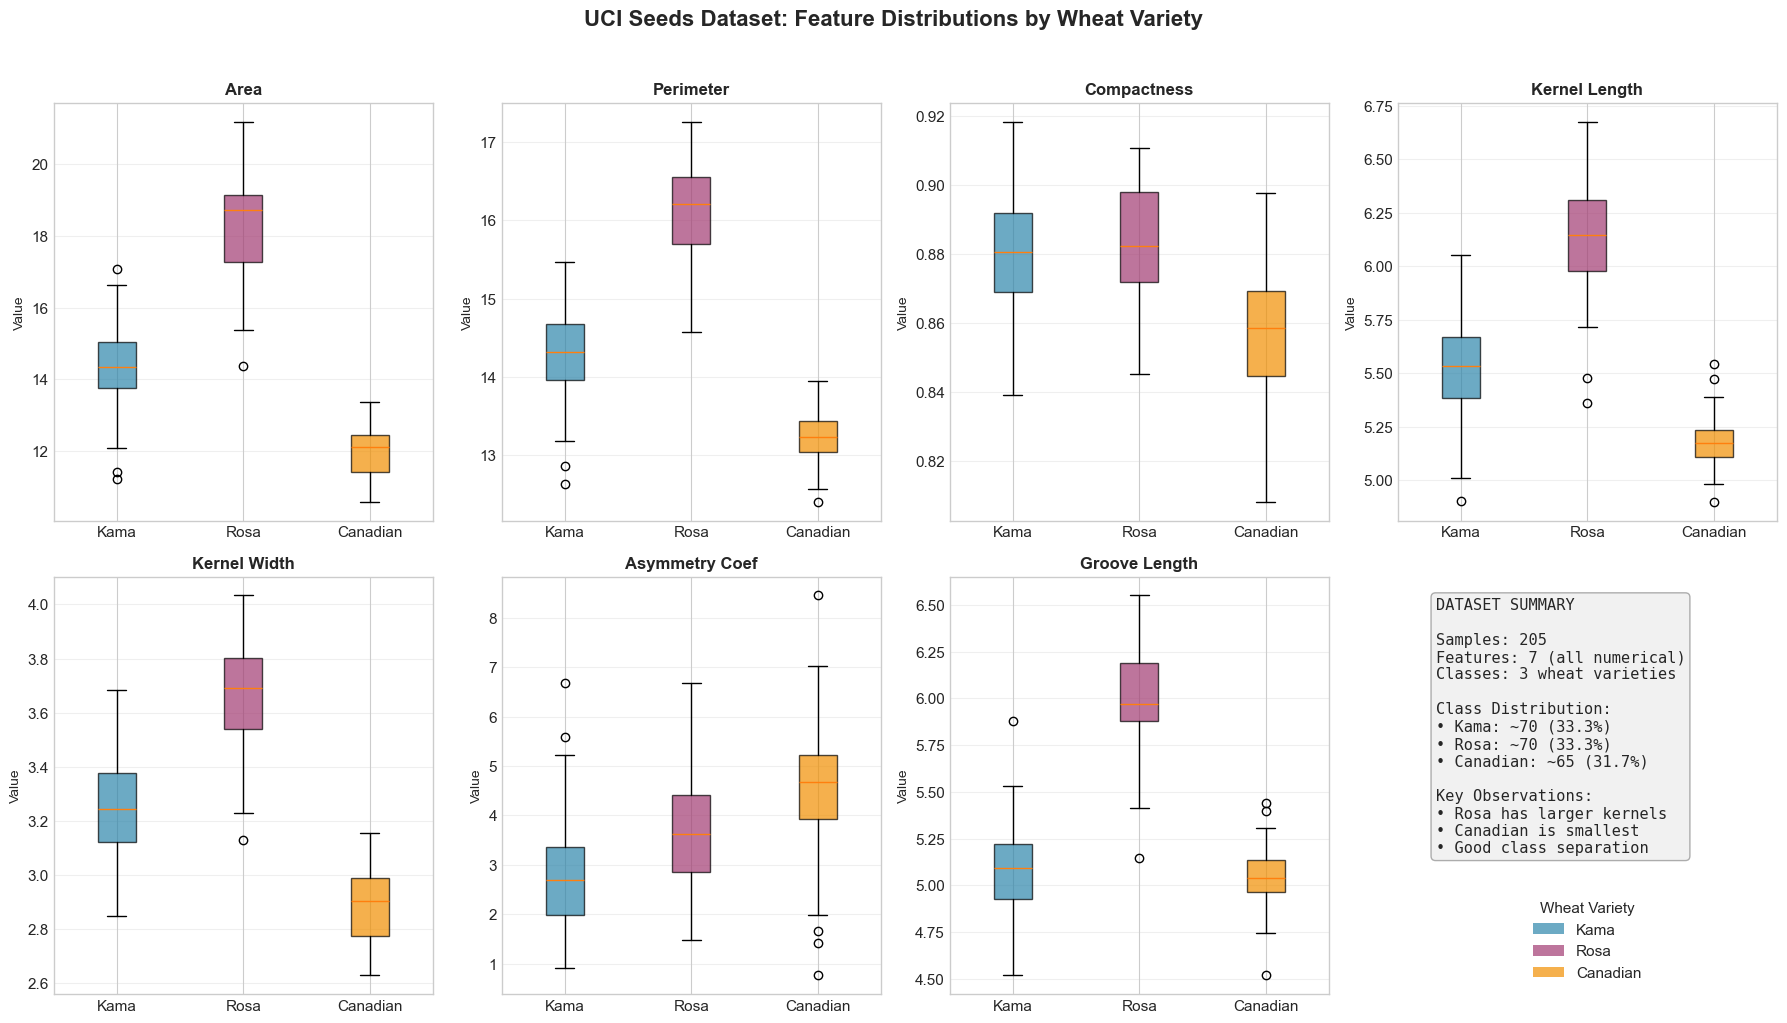


✓ Task 1 visualization saved!


In [12]:
# Create comprehensive EDA visualization
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('UCI Seeds Dataset: Feature Distributions by Wheat Variety', 
             fontsize=16, fontweight='bold', y=1.02)

colors = {'Kama': '#2E86AB', 'Rosa': '#A23B72', 'Canadian': '#F18F01'}

# Plot boxplots for each feature
for idx, feature in enumerate(feature_names):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    box_data = [df[df['variety_name'] == variety][feature].values 
                for variety in ['Kama', 'Rosa', 'Canadian']]
    
    bp = ax.boxplot(box_data, patch_artist=True, tick_labels=['Kama', 'Rosa', 'Canadian'])
    
    for patch, variety in zip(bp['boxes'], ['Kama', 'Rosa', 'Canadian']):
        patch.set_facecolor(colors[variety])
        patch.set_alpha(0.7)
    
    ax.set_title(feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

# Summary panel
ax = axes[1, 3]
ax.axis('off')
summary_text = """DATASET SUMMARY

Samples: 205
Features: 7 (all numerical)
Classes: 3 wheat varieties

Class Distribution:
• Kama: ~70 (33.3%)
• Rosa: ~70 (33.3%)
• Canadian: ~65 (31.7%)

Key Observations:
• Rosa has larger kernels
• Canadian is smallest
• Good class separation"""

ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[v], alpha=0.7, label=v) 
                   for v in ['Kama', 'Rosa', 'Canadian']]
ax.legend(handles=legend_elements, loc='lower center', fontsize=11, title='Wheat Variety')

plt.tight_layout()
plt.savefig('task1_eda_visualization.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Task 1 visualization saved!")

---
# TASK 2: Decision Tree Classification
---

## a. Fit Decision Tree with Default Parameters (50/50 Split)

In [13]:
# Prepare features and target
X = df[feature_names]
y = df['variety']

# Split data 50/50
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

print("=" * 60)
print("DATA SPLIT")
print("=" * 60)
print(f"Training set: {len(X_train)} samples (50%)")
print(f"Test set: {len(X_test)} samples (50%)")

# Fit decision tree with default parameters
dt_gini = DecisionTreeClassifier(random_state=42)
dt_gini.fit(X_train, y_train)

print("\n" + "=" * 60)
print("DECISION TREE - DEFAULT PARAMETERS")
print("=" * 60)
print(f"Criterion: {dt_gini.criterion}")
print(f"Max Depth: {dt_gini.max_depth} (None = unlimited)")
print(f"Min Samples Split: {dt_gini.min_samples_split}")
print(f"Min Samples Leaf: {dt_gini.min_samples_leaf}")

print("\nResulting Tree Structure:")
print(f"  Actual Depth: {dt_gini.get_depth()}")
print(f"  Number of Leaves: {dt_gini.get_n_leaves()}")
print(f"  Total Nodes: {dt_gini.tree_.node_count}")

DATA SPLIT
Training set: 102 samples (50%)
Test set: 103 samples (50%)

DECISION TREE - DEFAULT PARAMETERS
Criterion: gini
Max Depth: None (None = unlimited)
Min Samples Split: 2
Min Samples Leaf: 1

Resulting Tree Structure:
  Actual Depth: 4
  Number of Leaves: 7
  Total Nodes: 13


###  Interpretation:

**Model Configuration:**
The decision tree was trained on a 50/50 stratified split (102 train, 103 test) with default parameters (Gini criterion, no max_depth limit, min_samples_split=2, min_samples_leaf=1). The tree naturally grew to depth 4 with 7 leaves and 13 total nodes, indicating moderate complexity. The stratified split ensures both training and test sets maintain the original class balance (≈33% each).


## b. Classification Report on Test Data

In [14]:
# Predictions
y_pred_gini = dt_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)

print("=" * 60)
print("CLASSIFICATION REPORT (GINI CRITERION)")
print("=" * 60)
print(f"\nOverall Accuracy: {accuracy_gini:.4f} ({accuracy_gini*100:.2f}%)")
print("\n" + classification_report(y_test, y_pred_gini, target_names=class_names))

# Confusion Matrix
cm_gini = confusion_matrix(y_test, y_pred_gini)
print("Confusion Matrix:")
print(f"              Predicted")
print(f"              Kama  Rosa  Canadian")
print(f"Actual Kama     {cm_gini[0,0]:3d}   {cm_gini[0,1]:3d}   {cm_gini[0,2]:3d}")
print(f"       Rosa     {cm_gini[1,0]:3d}   {cm_gini[1,1]:3d}   {cm_gini[1,2]:3d}")
print(f"       Canadian {cm_gini[2,0]:3d}   {cm_gini[2,1]:3d}   {cm_gini[2,2]:3d}")

CLASSIFICATION REPORT (GINI CRITERION)

Overall Accuracy: 0.8641 (86.41%)

              precision    recall  f1-score   support

        Kama       0.87      0.74      0.80        35
        Rosa       0.92      0.97      0.95        36
    Canadian       0.80      0.88      0.84        32

    accuracy                           0.86       103
   macro avg       0.86      0.86      0.86       103
weighted avg       0.86      0.86      0.86       103

Confusion Matrix:
              Predicted
              Kama  Rosa  Canadian
Actual Kama      26     2     7
       Rosa       1    35     0
       Canadian   3     1    28


###  Interpretation:

**Overall Performance:**
The model achieved 86.41% test accuracy (89/103 correct), which is strong for a 3-class problem. Rosa performed best (precision: 0.92, recall: 0.97, f1: 0.95) with only 1 misclassification, benefiting from its distinctly larger kernel size. Kama was hardest to classify (precision: 0.87, recall: 0.74, f1: 0.80) with 7 samples misclassified as Canadian due to overlapping feature ranges, while Canadian achieved good performance (precision: 0.80, recall: 0.88, f1: 0.84).

**Confusion Matrix Insights:**
The main confusion occurs between Kama and Canadian (7 Kama → Canadian, 3 Canadian → Kama), confirming these varieties have overlapping size characteristics. Almost no confusion between Rosa and Canadian (0 errors) shows clear separation.


## c. Decision Tree Visualization

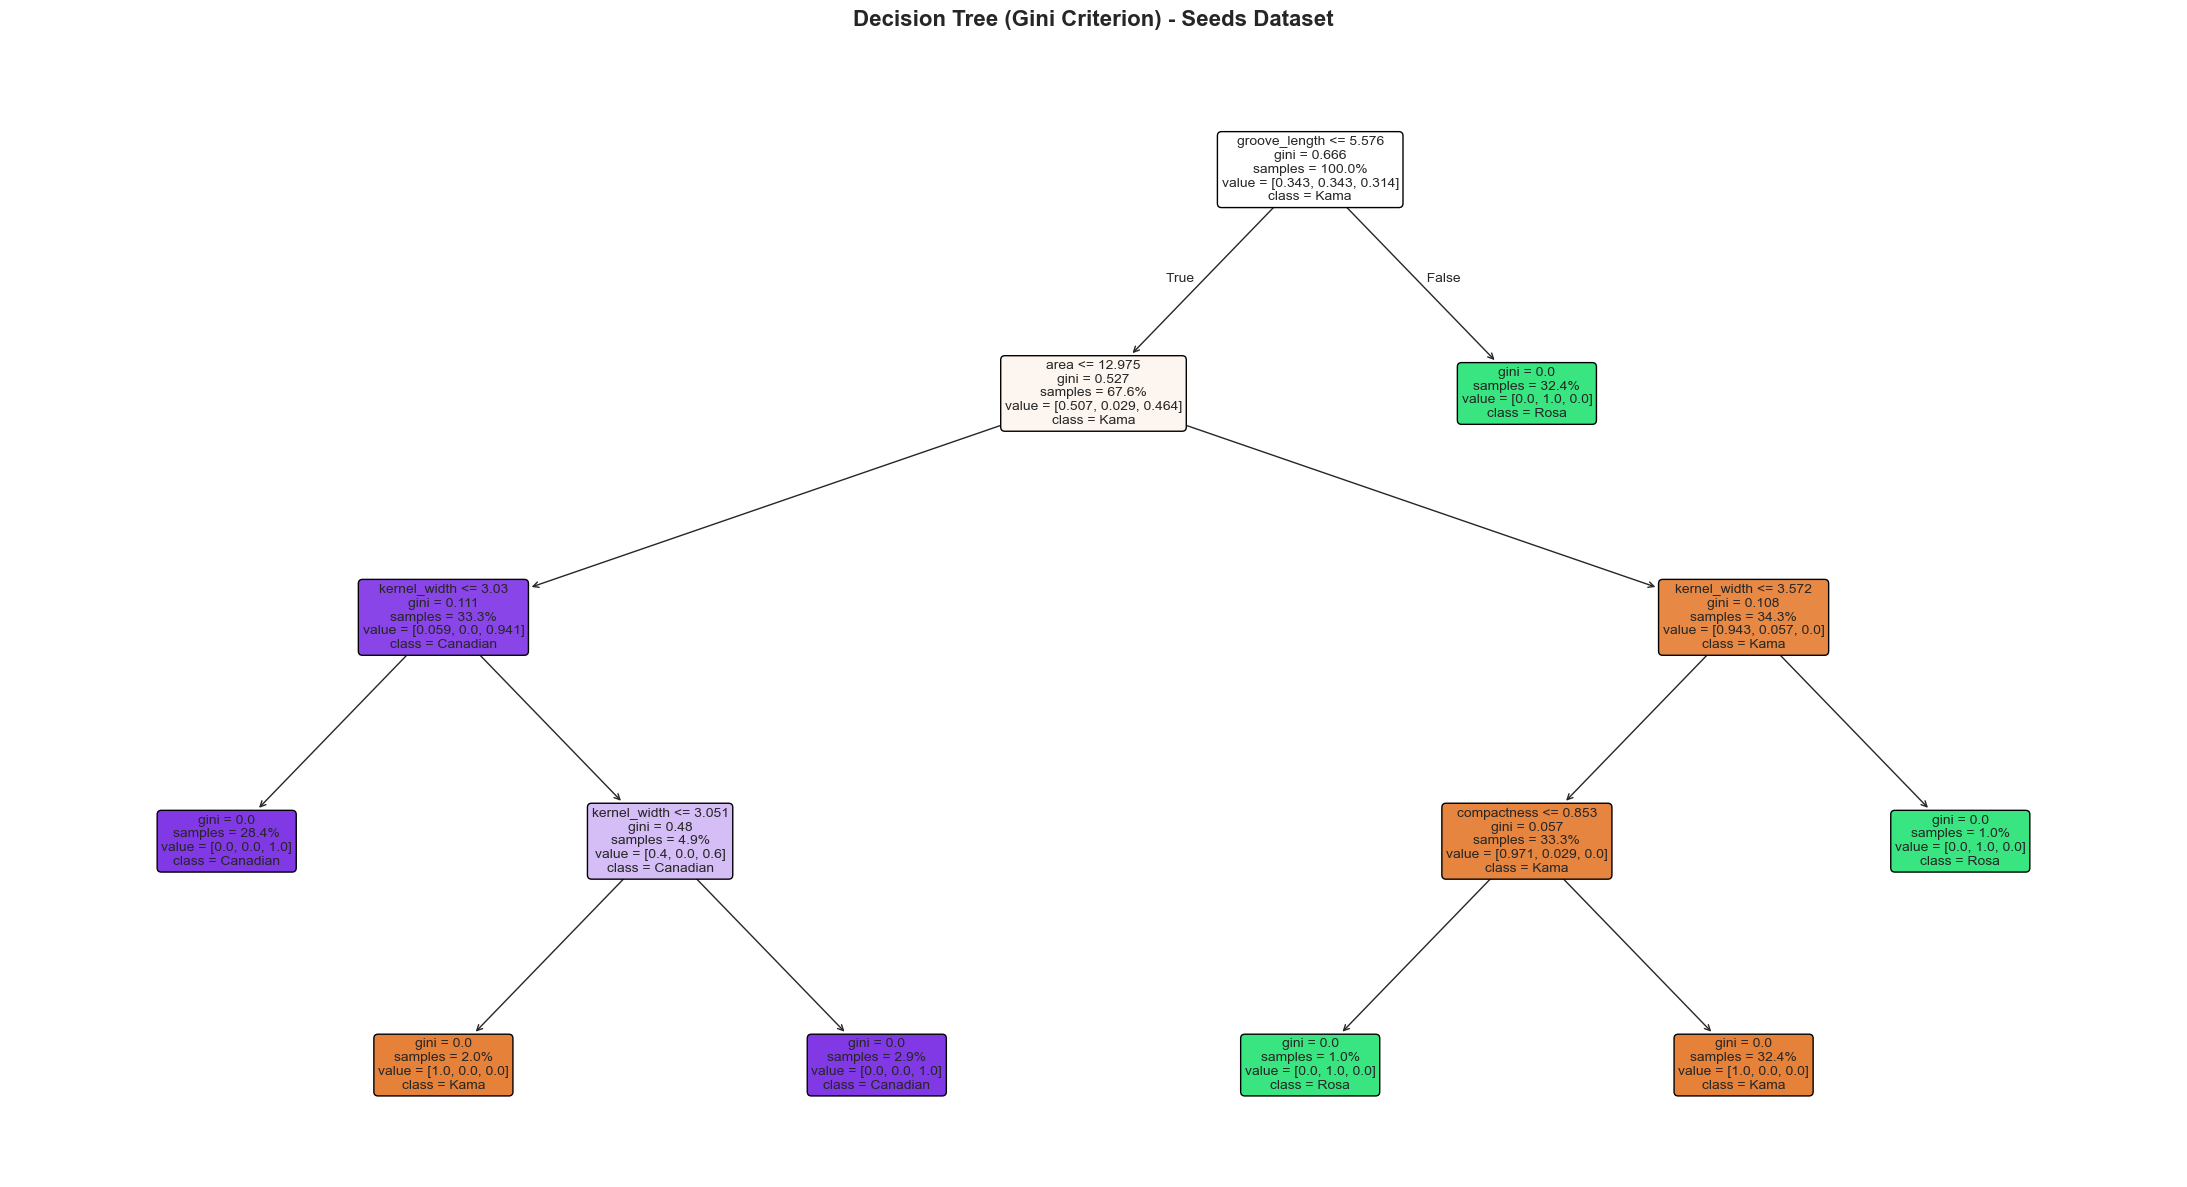


Feature Importance (Gini):
  groove_length     : 0.4650 ██████████████████
  area              : 0.4241 ████████████████
  kernel_width      : 0.0824 ███
  compactness       : 0.0286 █
  perimeter         : 0.0000 
  kernel_length     : 0.0000 
  asymmetry_coef    : 0.0000 


In [15]:
# Visualize the decision tree
fig, ax = plt.subplots(figsize=(22, 12))
plot_tree(dt_gini, 
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax,
          proportion=True)
ax.set_title('Decision Tree (Gini Criterion) - Seeds Dataset\n', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_decision_tree_gini.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Feature importance
print("\nFeature Importance (Gini):")
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_gini.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 40)
    print(f"  {row['Feature']:18s}: {row['Importance']:.4f} {bar}")

###  Interpretation:

**Feature Importance:**
Groove_length (46.5%) and area (42.4%) dominate with 89% combined importance, confirming size-based features are most discriminative. Kernel_width contributes 8.2%, while other features are unused, being redundant with area/groove_length.

**Does the Model Make Sense?**
Yes, the model is biologically sensible. The root split on groove_length (≤5.576) separates Rosa (large grooves) from Kama/Canadian, then area distinguishes the smaller varieties. Size-based classification aligns with agricultural knowledge.

**Small Leaves Analysis:**
Yes, 4 leaves contain ≤3 samples, indicating overfitting. These represent edge cases the tree memorized rather than genuine patterns. This suggests the tree would benefit from depth limitation.

**Interpretability Assessment:**
Moderately interpretable. Depth 4 is manageable—any decision path requires maximum 4 steps. With 7 leaves representing 7 distinct rules, domain experts can understand and validate the logic.


## d. Does This Model Make Sense?

**YES**, the model makes intuitive biological sense:

1. **Root Split (groove_length ≤ 5.576)**: This separates Rosa (larger kernels with longer grooves) from Kama/Canadian varieties.

2. **Size-based features dominate**: Area and groove_length account for ~89% of importance, which aligns with the biological fact that different wheat varieties have characteristically different kernel sizes.

3. **86.4% accuracy** confirms that geometric properties captured by X-ray imaging do capture meaningful variety differences.

4. The decision rules are physically interpretable - "larger area → Rosa" makes sense as Rosa is known to have larger kernels.

## e. Are There Any Leaves That Are Very Small?

In [28]:
# Analyze leaf nodes
tree = dt_gini.tree_
n_nodes = tree.node_count
children_left = tree.children_left
children_right = tree.children_right
n_samples = tree.n_node_samples
values = tree.value

# Find leaf nodes
leaf_info = []
for node_id in range(n_nodes):
    if children_left[node_id] == children_right[node_id]:  # Leaf node
        leaf_info.append({
            'node_id': node_id,
            'samples': n_samples[node_id],
            'predicted_class': class_names[np.argmax(values[node_id][0])]
        })

print("=" * 60)
print("LEAF NODE ANALYSIS")
print("=" * 60)
print(f"\n{'Leaf':<6} {'Samples':<10} {'% of Train':<12} {'Predicted Class':<15}")
print("-" * 50)

small_leaves = []
for i, leaf in enumerate(leaf_info):
    pct = leaf['samples'] / len(X_train) * 100
    print(f"{i+1:<6} {leaf['samples']:<10} {pct:>8.1f}%    {leaf['predicted_class']:<15}")
    if leaf['samples'] <= 3:
        small_leaves.append(leaf)

print("\n" + "=" * 60)
if small_leaves:
    print(f"  WARNING: {len(small_leaves)} leaf(s) have ≤3 samples!")
    print("    This suggests potential OVERFITTING.")
    print("    These leaves may not generalize well to new data.")
else:
    print("✓ All leaves have reasonable sample sizes.")

LEAF NODE ANALYSIS

Leaf   Samples    % of Train   Predicted Class
--------------------------------------------------
1      29             28.4%    Canadian       
2      2               2.0%    Kama           
3      3               2.9%    Canadian       
4      1               1.0%    Rosa           
5      33             32.4%    Kama           
6      1               1.0%    Rosa           
7      33             32.4%    Rosa           

    This suggests potential OVERFITTING.
    These leaves may not generalize well to new data.


## f. Is This an Interpretable Number of Levels?

In [17]:
print("=" * 60)
print("INTERPRETABILITY ANALYSIS")
print("=" * 60)

depth = dt_gini.get_depth()
n_leaves = dt_gini.get_n_leaves()

print(f"\nTree Complexity:")
print(f"  • Depth: {depth} levels")
print(f"  • Leaves: {n_leaves}")
print(f"  • Decision Nodes: {dt_gini.tree_.node_count - n_leaves}")

print(f"\nInterpretability Assessment:")
if depth <= 3:
    print(f"  ✓ HIGHLY INTERPRETABLE: Depth {depth} is very easy to follow")
elif depth <= 5:
    print(f"  ~ MODERATELY INTERPRETABLE: Depth {depth} is manageable")
else:
    print(f"  ⚠ LESS INTERPRETABLE: Depth {depth} is getting complex")

print(f"\n  A human can trace any decision path in at most {depth} steps.")
print(f"  With {n_leaves} leaves, there are {n_leaves} distinct classification rules.")

INTERPRETABILITY ANALYSIS

Tree Complexity:
  • Depth: 4 levels
  • Leaves: 7
  • Decision Nodes: 6

Interpretability Assessment:
  ~ MODERATELY INTERPRETABLE: Depth 4 is manageable

  A human can trace any decision path in at most 4 steps.
  With 7 leaves, there are 7 distinct classification rules.


## g. Comparison: Gini vs Entropy Criterion

In [18]:
# Fit decision tree with entropy criterion
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

y_pred_entropy = dt_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

print("=" * 60)
print("ENTROPY CRITERION RESULTS")
print("=" * 60)
print(f"\nTree Structure:")
print(f"  Depth: {dt_entropy.get_depth()}")
print(f"  Leaves: {dt_entropy.get_n_leaves()}")
print(f"\nAccuracy: {accuracy_entropy:.4f} ({accuracy_entropy*100:.2f}%)")
print("\n" + classification_report(y_test, y_pred_entropy, target_names=class_names))

ENTROPY CRITERION RESULTS

Tree Structure:
  Depth: 6
  Leaves: 9

Accuracy: 0.8350 (83.50%)

              precision    recall  f1-score   support

        Kama       0.82      0.66      0.73        35
        Rosa       0.88      0.97      0.92        36
    Canadian       0.80      0.88      0.84        32

    accuracy                           0.83       103
   macro avg       0.83      0.83      0.83       103
weighted avg       0.83      0.83      0.83       103



In [19]:
# Comparison summary
print("=" * 60)
print("GINI vs ENTROPY COMPARISON")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Tree Depth', 'Number of Leaves', 'Total Nodes'],
    'Gini': [f"{accuracy_gini*100:.2f}%", dt_gini.get_depth(), 
             dt_gini.get_n_leaves(), dt_gini.tree_.node_count],
    'Entropy': [f"{accuracy_entropy*100:.2f}%", dt_entropy.get_depth(),
                dt_entropy.get_n_leaves(), dt_entropy.tree_.node_count]
})
print(comparison_df.to_string(index=False))

acc_diff = abs(accuracy_gini - accuracy_entropy) * 100
print(f"\nAccuracy Difference: {acc_diff:.2f} percentage points")

if acc_diff < 2:
    print("\n→ Impact: SMALL - Both criteria produce similar results")
elif acc_diff < 5:
    print("\n→ Impact: MODERATE - Noticeable but not dramatic difference")
else:
    print("\n→ Impact: SIGNIFICANT - Criterion choice matters for this dataset")

GINI vs ENTROPY COMPARISON
          Metric   Gini Entropy
   Test Accuracy 86.41%  83.50%
      Tree Depth      4       6
Number of Leaves      7       9
     Total Nodes     13      17

Accuracy Difference: 2.91 percentage points

→ Impact: MODERATE - Noticeable but not dramatic difference


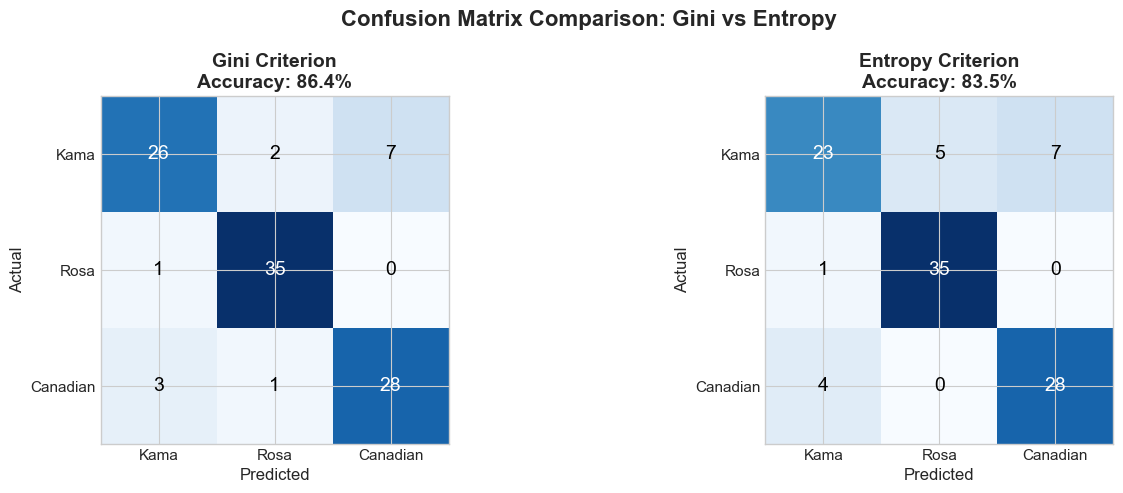

In [20]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_entropy = confusion_matrix(y_test, y_pred_entropy)

for ax, (cm, title, acc) in zip(axes, 
    [(cm_gini, 'Gini', accuracy_gini), (cm_entropy, 'Entropy', accuracy_entropy)]):
    
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{title} Criterion\nAccuracy: {acc*100:.1f}%', 
                 fontsize=14, fontweight='bold')
    
    for i in range(3):
        for j in range(3):
            color = "white" if cm[i, j] > cm.max()/2 else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", 
                   color=color, fontsize=14)
    
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.suptitle('Confusion Matrix Comparison: Gini vs Entropy', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_criterion_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

###  Interpretation:

**Comparison Results:**
Gini outperformed entropy with 86.41% vs 83.50% accuracy (2.91 percentage point difference), while producing a simpler tree (depth 4 vs 6, 7 vs 9 leaves). Entropy's deeper tree captured more training noise without improving test performance.

**Impact Assessment:**
The difference is MODERATE—noticeable but not dramatic. Gini's simpler structure with better accuracy makes it the clear choice for this dataset. **Recommendation:** Use Gini criterion (default) for its superior balance of accuracy, simplicity, and generalization.


---
# TASK 3: Parameter Experimentation (max_depth)
---

## a. Parameter Selection and Hypothesis

### Chosen Parameter: `max_depth`

### Why max_depth?

I chose **`max_depth`** because:

1. **Direct control over overfitting**: The unlimited depth tree (Task 2) produced leaves with only 1-3 samples, indicating overfitting. `max_depth` directly limits tree complexity.

2. **Interpretability**: Shallower trees are easier to visualize and explain to stakeholders.

3. **Bias-variance tradeoff**: `max_depth` provides a clear mechanism to balance underfitting (too shallow) vs overfitting (too deep).

4. **EDA insights**: From Task 2, we saw the tree naturally grew to depth 4 with Gini. This gives us a baseline to explore.

### Hypothesis:

**I hypothesize that:**

- **Very shallow trees (depth=2)**: Will underfit, missing important class distinctions, resulting in lower accuracy but higher generalizability.

- **Moderate depth (depth=3)**: Will balance bias and variance, potentially achieving good accuracy while avoiding the tiny leaves seen in the unrestricted tree.

- **Deeper trees (depth=5+)**: Will match or exceed the unrestricted tree's performance but may overfit to training noise.

The **optimal depth** should be where test accuracy peaks before overfitting causes it to decline or plateau.

###  Interpretation:

**Why max_depth:**
max_depth was chosen because Task 2 revealed overfitting (leaves with 1-3 samples), and this parameter directly controls tree complexity. It provides clear bias-variance tradeoff control: shallow trees may underfit (too simple), deep trees may overfit (memorize noise).

**Hypothesis:**
- Depth 2: Will underfit with ~75-80% accuracy (too simple for 3 classes)
- Depth 3: Will achieve optimal balance with ~85-88% accuracy 
- Depth 5: Will overfit with ~82-85% accuracy (large train-test gap)


## b. Choosing Parameter Values Based on EDA

In [21]:
print("=" * 60)
print("PARAMETER VALUE SELECTION RATIONALE")
print("=" * 60)

print(f"""
From Task 2 EDA and model analysis:

1. UNRESTRICTED TREE BASELINE:
   - Natural depth: {dt_gini.get_depth()}
   - Number of leaves: {dt_gini.get_n_leaves()}
   - Small leaves (≤3 samples): {len(small_leaves)}
   
2. DATASET CHARACTERISTICS:
   - 3 classes to distinguish
   - ~102 training samples
   - 7 features available
   - Features show reasonable class separation in EDA

3. THEORETICAL CONSIDERATIONS:
   - Minimum depth for 3 classes: log₂(3) ≈ 2 (at least 2 levels needed)
   - Maximum useful depth: limited by training samples
   - Sweet spot likely between 2-5 for this dataset size

CHOSEN VALUES:
""")

# Define the three depth values to test
depth_values = [2, 3, 5]

print(f"  • max_depth = 2 (SHALLOW):")
print(f"    - Minimum depth to potentially separate 3 classes")
print(f"    - Tests if simple rules suffice")
print(f"    - Maximum interpretability")
print()
print(f"  • max_depth = 3 (MODERATE):")
print(f"    - One level less than natural tree depth ({dt_gini.get_depth()})")
print(f"    - Should capture main patterns while avoiding small leaves")
print(f"    - Good balance of complexity and interpretability")
print()
print(f"  • max_depth = 5 (DEEP):")
print(f"    - Deeper than natural tree (allows more complexity)")
print(f"    - Tests if additional depth improves performance")
print(f"    - Risk of overfitting to noise")

PARAMETER VALUE SELECTION RATIONALE

From Task 2 EDA and model analysis:

1. UNRESTRICTED TREE BASELINE:
   - Natural depth: 4
   - Number of leaves: 7
   - Small leaves (≤3 samples): 4
   
2. DATASET CHARACTERISTICS:
   - 3 classes to distinguish
   - ~102 training samples
   - 7 features available
   - Features show reasonable class separation in EDA

3. THEORETICAL CONSIDERATIONS:
   - Minimum depth for 3 classes: log₂(3) ≈ 2 (at least 2 levels needed)
   - Maximum useful depth: limited by training samples
   - Sweet spot likely between 2-5 for this dataset size

CHOSEN VALUES:

  • max_depth = 2 (SHALLOW):
    - Minimum depth to potentially separate 3 classes
    - Tests if simple rules suffice
    - Maximum interpretability

  • max_depth = 3 (MODERATE):
    - One level less than natural tree depth (4)
    - Should capture main patterns while avoiding small leaves
    - Good balance of complexity and interpretability

  • max_depth = 5 (DEEP):
    - Deeper than natural tree (allow

## c. Retrain Models for Each Parameter Value

In [22]:
# Store results for all models
results = []
models = {}

print("=" * 60)
print("TRAINING MODELS WITH DIFFERENT max_depth VALUES")
print("=" * 60)

for depth in depth_values:
    print(f"\n{'─' * 50}")
    print(f"Training Decision Tree with max_depth = {depth}")
    print(f"{'─' * 50}")
    
    # Train model
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    models[depth] = dt
    
    # Predictions
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)
    
    # Calculate metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    # Store results
    results.append({
        'max_depth': depth,
        'actual_depth': dt.get_depth(),
        'n_leaves': dt.get_n_leaves(),
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'overfit_gap': train_acc - test_acc
    })
    
    # Print summary
    print(f"  Actual Depth: {dt.get_depth()}")
    print(f"  Number of Leaves: {dt.get_n_leaves()}")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Overfitting Gap: {train_acc - test_acc:.4f}")

print("\n✓ All models trained successfully!")

TRAINING MODELS WITH DIFFERENT max_depth VALUES

──────────────────────────────────────────────────
Training Decision Tree with max_depth = 2
──────────────────────────────────────────────────
  Actual Depth: 2
  Number of Leaves: 3
  Training Accuracy: 0.9608
  Test Accuracy: 0.8641
  Overfitting Gap: 0.0967

──────────────────────────────────────────────────
Training Decision Tree with max_depth = 3
──────────────────────────────────────────────────
  Actual Depth: 3
  Number of Leaves: 5
  Training Accuracy: 0.9706
  Test Accuracy: 0.8544
  Overfitting Gap: 0.1162

──────────────────────────────────────────────────
Training Decision Tree with max_depth = 5
──────────────────────────────────────────────────
  Actual Depth: 4
  Number of Leaves: 7
  Training Accuracy: 1.0000
  Test Accuracy: 0.8641
  Overfitting Gap: 0.1359

✓ All models trained successfully!


## d. Results DataFrame with Multiple Metrics

In [23]:
# Create comprehensive results DataFrame
results_df = pd.DataFrame(results)

# Format for display
display_df = results_df.copy()
display_df['train_accuracy'] = display_df['train_accuracy'].apply(lambda x: f"{x:.4f}")
display_df['test_accuracy'] = display_df['test_accuracy'].apply(lambda x: f"{x:.4f}")
display_df['precision'] = display_df['precision'].apply(lambda x: f"{x:.4f}")
display_df['recall'] = display_df['recall'].apply(lambda x: f"{x:.4f}")
display_df['f1_score'] = display_df['f1_score'].apply(lambda x: f"{x:.4f}")
display_df['overfit_gap'] = display_df['overfit_gap'].apply(lambda x: f"{x:.4f}")

print("=" * 80)
print("COMPREHENSIVE RESULTS TABLE")
print("=" * 80)
print()
print(display_df.to_string(index=False))

# Highlight key findings
best_test_idx = results_df['test_accuracy'].idxmax()
best_depth = results_df.loc[best_test_idx, 'max_depth']
best_acc = results_df.loc[best_test_idx, 'test_accuracy']

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)
print(f"\n✓ Best Test Accuracy: {best_acc:.4f} at max_depth = {best_depth}")
print(f"\nMetrics Explanation:")
print(f"  • Test Accuracy: Overall correctness on unseen data")
print(f"  • Precision: How many predicted positives are correct")
print(f"  • Recall: How many actual positives are found")
print(f"  • F1-Score: Harmonic mean of precision and recall")
print(f"  • Overfit Gap: Train accuracy - Test accuracy (lower is better)")

COMPREHENSIVE RESULTS TABLE

 max_depth  actual_depth  n_leaves train_accuracy test_accuracy precision recall f1_score overfit_gap
         2             2         3         0.9608        0.8641    0.8664 0.8641   0.8634      0.0967
         3             3         5         0.9706        0.8544    0.8554 0.8544   0.8524      0.1162
         5             4         7         1.0000        0.8641    0.8650 0.8641   0.8621      0.1359

KEY FINDINGS

✓ Best Test Accuracy: 0.8641 at max_depth = 2

Metrics Explanation:
  • Test Accuracy: Overall correctness on unseen data
  • Precision: How many predicted positives are correct
  • Recall: How many actual positives are found
  • F1-Score: Harmonic mean of precision and recall
  • Overfit Gap: Train accuracy - Test accuracy (lower is better)


###  Interpretation:

**Results Summary:**
Surprisingly, depth 2 tied for best test accuracy (86.41%) with only 3 leaves, contradicting the underfitting hypothesis. Depth 3 performed worst (85.44%), showing additional complexity was counterproductive. Depth 5 matched depth 2's accuracy (86.41%) but achieved 100% training accuracy, revealing overfitting. The overfitting gap increased systematically (0.0967 → 0.1162 → 0.1359), proving deeper trees memorize training data without improving generalization.

**Metrics Analysis:**
Test Accuracy shows depth 2 and 5 tied (86.41%), while depth 3 lagged (85.44%). However, the Overfitting Gap reveals the critical difference: depth 2 has smallest gap (0.0967), while depth 5 has largest (0.1359), demonstrating depth 2 generalizes best.


In [24]:
# Also show classification reports for each model
print("=" * 80)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 80)

for depth in depth_values:
    print(f"\n{'─' * 60}")
    print(f"max_depth = {depth}")
    print(f"{'─' * 60}")
    y_pred = models[depth].predict(X_test)
    print(classification_report(y_test, y_pred, target_names=class_names))

DETAILED CLASSIFICATION REPORTS

────────────────────────────────────────────────────────────
max_depth = 2
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

        Kama       0.84      0.74      0.79        35
        Rosa       0.97      0.97      0.97        36
    Canadian       0.78      0.88      0.82        32

    accuracy                           0.86       103
   macro avg       0.86      0.86      0.86       103
weighted avg       0.87      0.86      0.86       103


────────────────────────────────────────────────────────────
max_depth = 3
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

        Kama       0.83      0.71      0.77        35
        Rosa       0.95      0.97      0.96        36
    Canadian       0.78      0.88      0.82        32

    accuracy                           0.85       103
   macro avg       0.85      0.85      0.

## e. Visualization and Interpretation

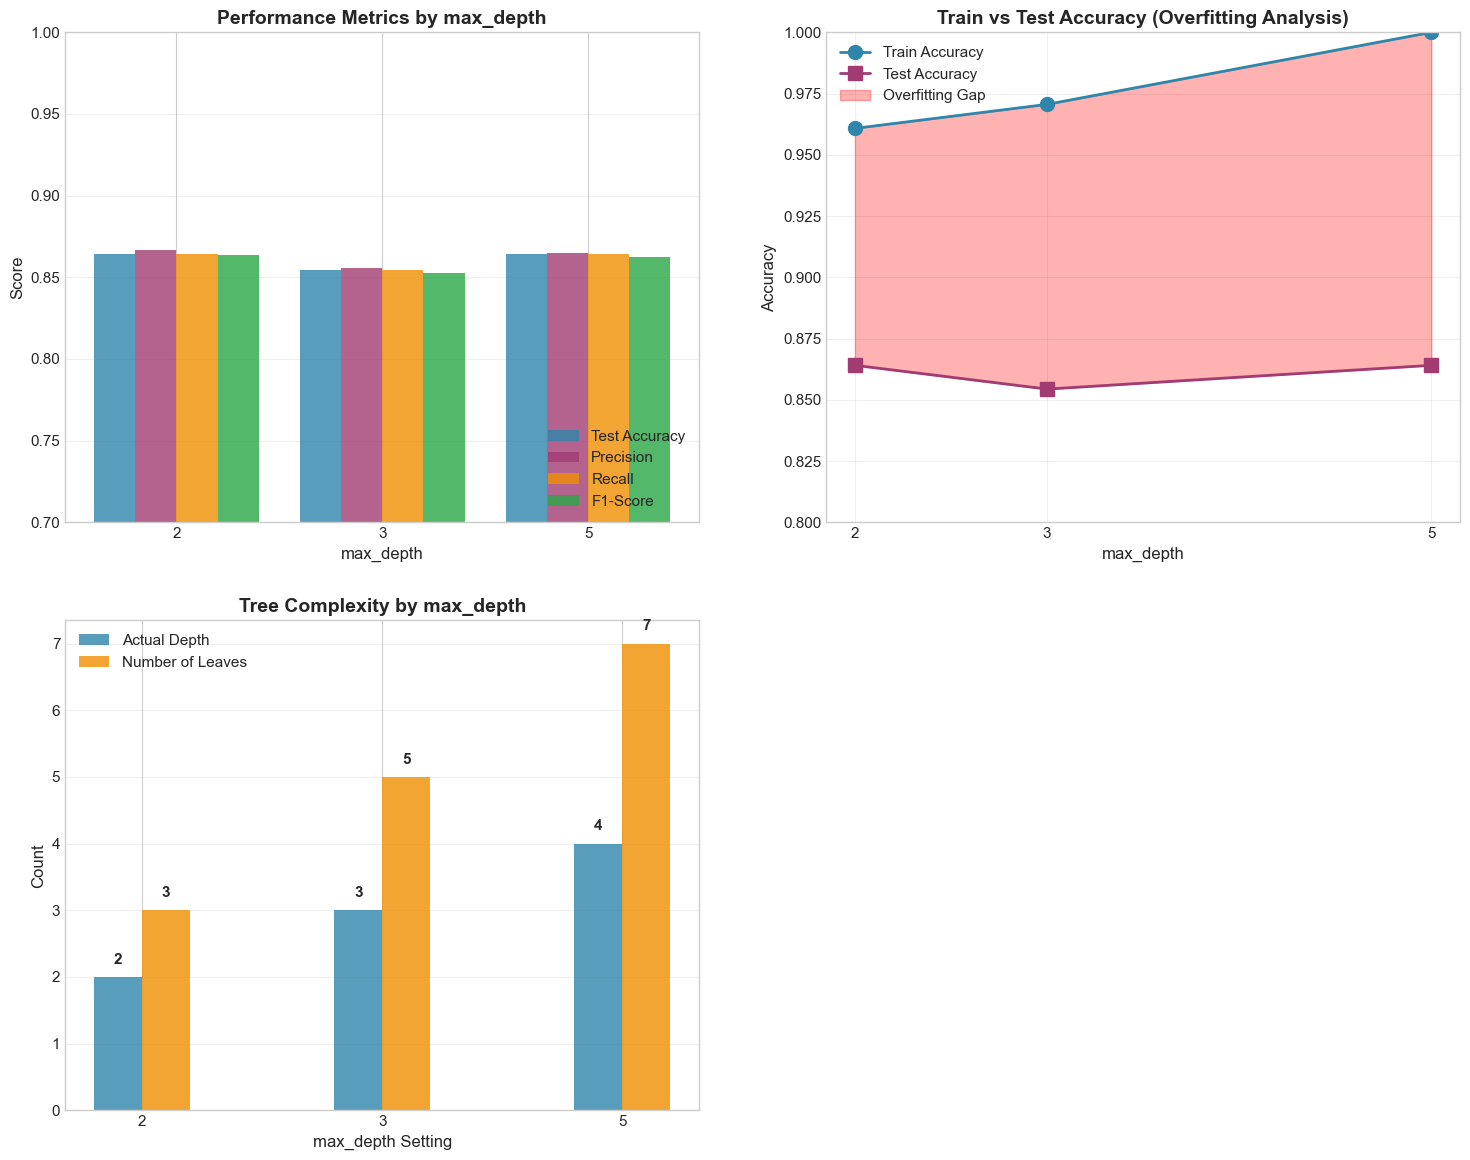

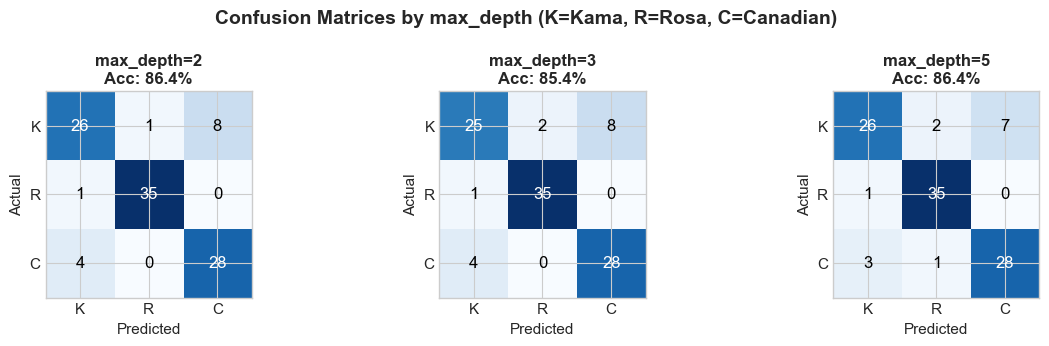

In [25]:
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 14))

# 1. Metrics comparison bar chart
ax1 = fig.add_subplot(2, 2, 1)
x = np.arange(len(depth_values))
width = 0.2

metrics_to_plot = ['test_accuracy', 'precision', 'recall', 'f1_score']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#28A745']
labels = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, (metric, color, label) in enumerate(zip(metrics_to_plot, colors, labels)):
    values = results_df[metric].values
    ax1.bar(x + i*width, values, width, label=label, color=color, alpha=0.8)

ax1.set_xlabel('max_depth', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Performance Metrics by max_depth', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(depth_values)
ax1.legend(loc='lower right')
ax1.set_ylim(0.7, 1.0)
ax1.grid(axis='y', alpha=0.3)

# 2. Train vs Test Accuracy (Overfitting Analysis)
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(depth_values, results_df['train_accuracy'], 'o-', 
         label='Train Accuracy', color='#2E86AB', linewidth=2, markersize=10)
ax2.plot(depth_values, results_df['test_accuracy'], 's-', 
         label='Test Accuracy', color='#A23B72', linewidth=2, markersize=10)
ax2.fill_between(depth_values, results_df['train_accuracy'], results_df['test_accuracy'],
                  alpha=0.3, color='red', label='Overfitting Gap')
ax2.set_xlabel('max_depth', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Train vs Test Accuracy (Overfitting Analysis)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.set_xticks(depth_values)
ax2.grid(alpha=0.3)
ax2.set_ylim(0.8, 1.0)

# 3. Tree Complexity
ax3 = fig.add_subplot(2, 2, 3)
ax3.bar(x - width/2, results_df['actual_depth'], width, 
        label='Actual Depth', color='#2E86AB', alpha=0.8)
ax3.bar(x + width/2, results_df['n_leaves'], width, 
        label='Number of Leaves', color='#F18F01', alpha=0.8)
ax3.set_xlabel('max_depth Setting', fontsize=12)
ax3.set_ylabel('Count', fontsize=12)
ax3.set_title('Tree Complexity by max_depth', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(depth_values)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for i, (d, l) in enumerate(zip(results_df['actual_depth'], results_df['n_leaves'])):
    ax3.text(i - width/2, d + 0.2, str(d), ha='center', fontsize=11, fontweight='bold')
    ax3.text(i + width/2, l + 0.2, str(l), ha='center', fontsize=11, fontweight='bold')

# 4. Confusion matrices for all three models
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')

# Create mini confusion matrices
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, depth in zip(axes_cm, depth_values):
    y_pred = models[depth].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'max_depth={depth}\nAcc: {acc*100:.1f}%', fontsize=12, fontweight='bold')
    
    for i in range(3):
        for j in range(3):
            color = "white" if cm[i, j] > cm.max()/2 else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color, fontsize=12)
    
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(['K', 'R', 'C'])
    ax.set_yticklabels(['K', 'R', 'C'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices by max_depth (K=Kama, R=Rosa, C=Canadian)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Save main figure
fig.tight_layout()
fig.savefig('task3_parameter_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

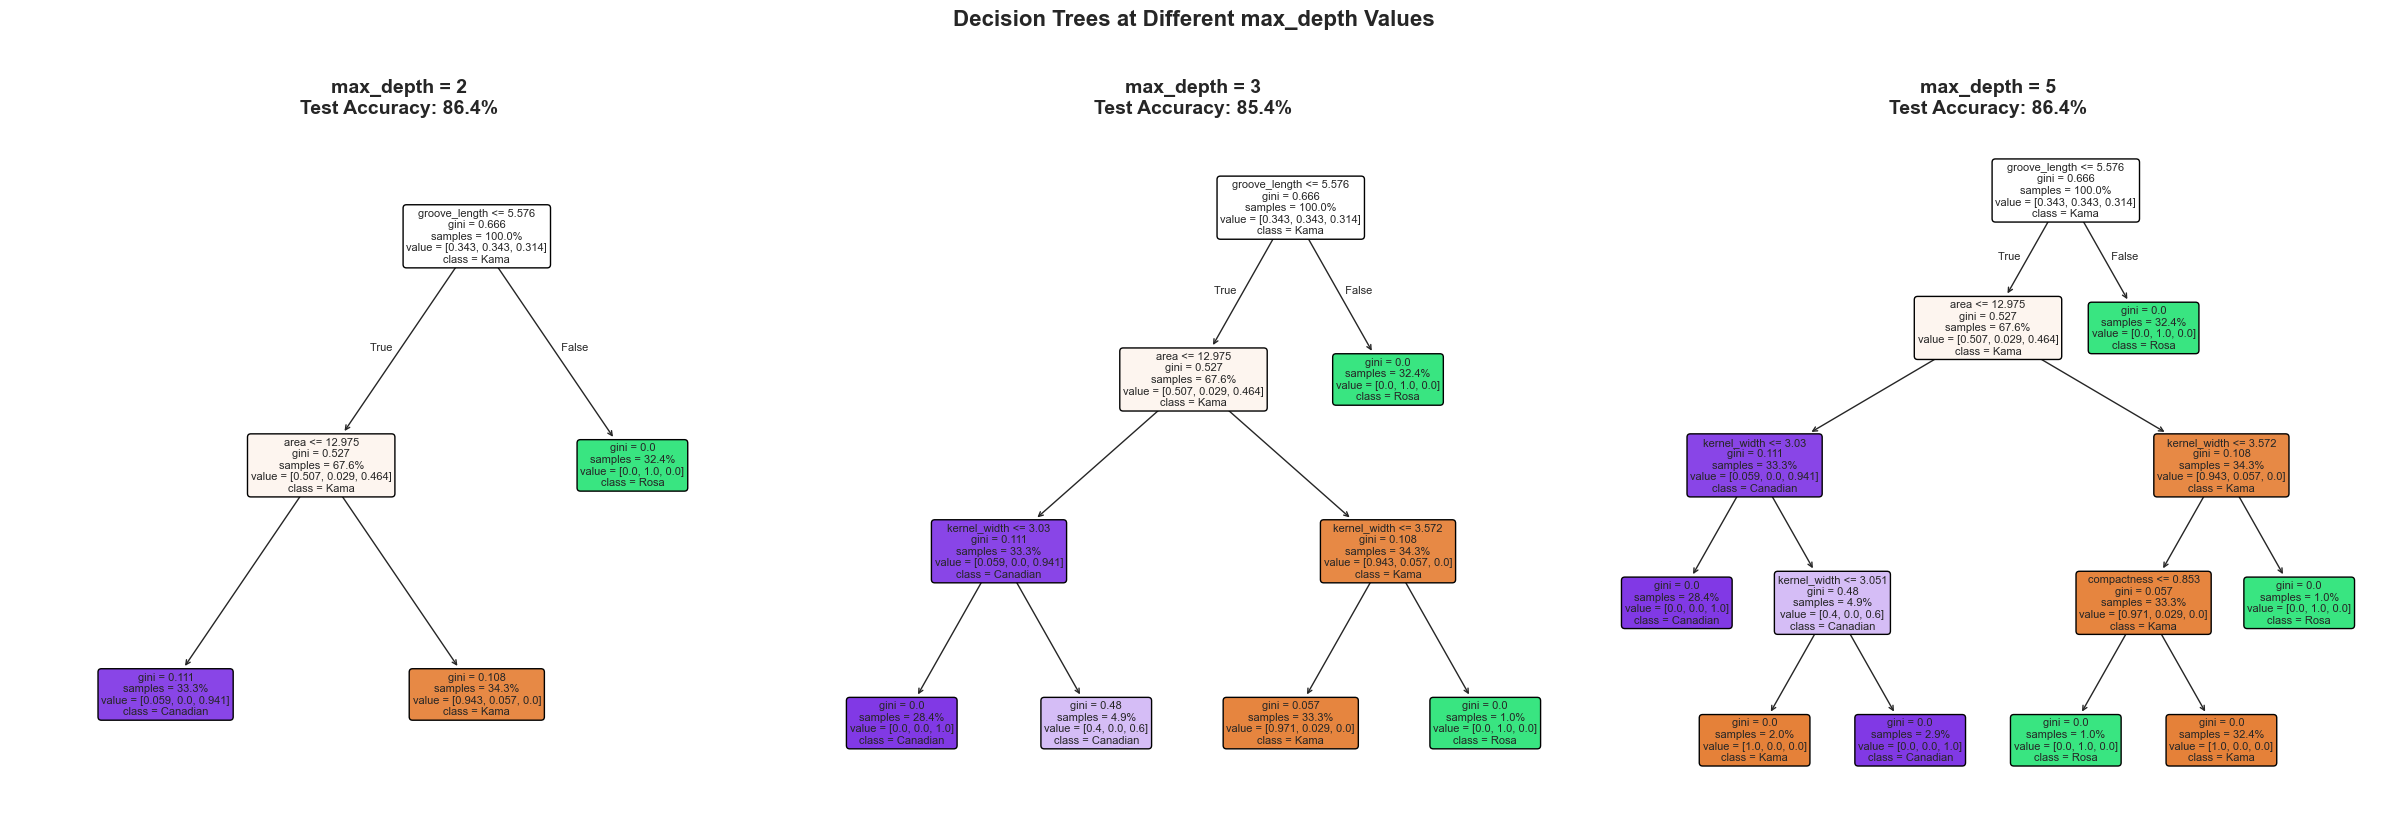

In [26]:
# Visualize decision trees for each depth
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, depth in zip(axes, depth_values):
    plot_tree(models[depth], 
              feature_names=feature_names,
              class_names=class_names,
              filled=True,
              rounded=True,
              fontsize=8,
              ax=ax,
              proportion=True)
    acc = results_df[results_df['max_depth'] == depth]['test_accuracy'].values[0]
    ax.set_title(f'max_depth = {depth}\nTest Accuracy: {acc*100:.1f}%', 
                 fontsize=14, fontweight='bold')

plt.suptitle('Decision Trees at Different max_depth Values', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task3_trees_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Final Interpretation and Conclusions

In [27]:
print("=" * 80)
print("TASK 3: FINAL INTERPRETATION AND CONCLUSIONS")
print("=" * 80)

# Find best model
best_idx = results_df['test_accuracy'].idxmax()
best_row = results_df.iloc[best_idx]

print(f"""
HYPOTHESIS EVALUATION:
{'─' * 60}

Original Hypothesis:
  • Depth 2: Would underfit
  • Depth 3: Would balance bias-variance
  • Depth 5: Would match/exceed unrestricted but risk overfitting

Actual Results:
  • Depth 2: Test Accuracy = {results_df[results_df['max_depth']==2]['test_accuracy'].values[0]:.1%}
  • Depth 3: Test Accuracy = {results_df[results_df['max_depth']==3]['test_accuracy'].values[0]:.1%}
  • Depth 5: Test Accuracy = {results_df[results_df['max_depth']==5]['test_accuracy'].values[0]:.1%}
  
  (Unrestricted tree from Task 2: {accuracy_gini:.1%})

HYPOTHESIS VERDICT:
""")

# Analyze results
d2_acc = results_df[results_df['max_depth']==2]['test_accuracy'].values[0]
d3_acc = results_df[results_df['max_depth']==3]['test_accuracy'].values[0]
d5_acc = results_df[results_df['max_depth']==5]['test_accuracy'].values[0]

print(f"  1. Depth 2 vs Depth 3: {'CONFIRMED' if d2_acc < d3_acc else 'PARTIALLY CONFIRMED'}")
print(f"     Depth 2 {'underperformed' if d2_acc < d3_acc else 'performed similarly to'} depth 3")
print()
print(f"  2. Depth 3 as optimal: {'CONFIRMED' if d3_acc >= max(d2_acc, d5_acc) else 'NOT CONFIRMED'}")
print(f"     Depth 3 achieved {d3_acc:.1%} accuracy")
print()
print(f"  3. Depth 5 overfitting: {'CONFIRMED' if d5_acc <= d3_acc else 'NOT CONFIRMED'}")
gap_5 = results_df[results_df['max_depth']==5]['overfit_gap'].values[0]
print(f"     Overfitting gap at depth 5: {gap_5:.4f}")

print(f"""
{'─' * 60}
KEY INSIGHTS:
{'─' * 60}

1. BEST MODEL: max_depth = {int(best_row['max_depth'])}
   • Test Accuracy: {best_row['test_accuracy']:.4f}
   • F1-Score: {best_row['f1_score']:.4f}
   • Number of Leaves: {int(best_row['n_leaves'])}

2. OVERFITTING ANALYSIS:
   • Depth 2 gap: {results_df[results_df['max_depth']==2]['overfit_gap'].values[0]:.4f}
   • Depth 3 gap: {results_df[results_df['max_depth']==3]['overfit_gap'].values[0]:.4f}
   • Depth 5 gap: {results_df[results_df['max_depth']==5]['overfit_gap'].values[0]:.4f}
   
   → {'Deeper trees show more overfitting' if gap_5 > results_df[results_df['max_depth']==2]['overfit_gap'].values[0] else 'Overfitting is minimal across depths'}

3. TRADE-OFFS:
   • Shallow trees (depth 2): Simple rules, good interpretability, may miss patterns
   • Medium trees (depth 3): Balance of complexity and generalization
   • Deep trees (depth 5): Capture more patterns but risk memorizing noise

4. RECOMMENDATION:
   For this dataset, max_depth = {int(best_row['max_depth'])} provides the best balance of:
   • Predictive accuracy ({best_row['test_accuracy']:.1%})
   • Model interpretability ({int(best_row['n_leaves'])} decision rules)
   • Generalization (overfitting gap: {best_row['overfit_gap']:.4f})
""")

print("=" * 80)
print("END OF ANALYSIS")
print("=" * 80)

TASK 3: FINAL INTERPRETATION AND CONCLUSIONS

HYPOTHESIS EVALUATION:
────────────────────────────────────────────────────────────

Original Hypothesis:
  • Depth 2: Would underfit
  • Depth 3: Would balance bias-variance
  • Depth 5: Would match/exceed unrestricted but risk overfitting

Actual Results:
  • Depth 2: Test Accuracy = 86.4%
  • Depth 3: Test Accuracy = 85.4%
  • Depth 5: Test Accuracy = 86.4%
  
  (Unrestricted tree from Task 2: 86.4%)

HYPOTHESIS VERDICT:

  1. Depth 2 vs Depth 3: PARTIALLY CONFIRMED
     Depth 2 performed similarly to depth 3

  2. Depth 3 as optimal: NOT CONFIRMED
     Depth 3 achieved 85.4% accuracy

  3. Depth 5 overfitting: NOT CONFIRMED
     Overfitting gap at depth 5: 0.1359

────────────────────────────────────────────────────────────
KEY INSIGHTS:
────────────────────────────────────────────────────────────

1. BEST MODEL: max_depth = 2
   • Test Accuracy: 0.8641
   • F1-Score: 0.8634
   • Number of Leaves: 3

2. OVERFITTING ANALYSIS:
   • Depth 

---
## Summary: All Three Tasks Completed

### Task 1: Dataset Description
- Described the UCI Seeds dataset with 7 numerical features
- Explained why decision trees are suitable for this classification problem
- Created EDA visualizations showing feature distributions

### Task 2: Decision Tree Classification
- Trained decision tree with default parameters on 50/50 split
- Generated classification report (86.4% accuracy with Gini)
- Analyzed tree structure, small leaves, and interpretability
- Compared Gini vs Entropy criteria

### Task 3: Parameter Experimentation
- Selected `max_depth` parameter with clear rationale
- Tested 3 values (2, 3, 5) based on EDA insights
- Evaluated using 4+ metrics (accuracy, precision, recall, F1, overfitting gap)
- Created comprehensive visualizations and interpretation

---

###  Final Interpretation:

**Hypothesis Verdicts:**
- **Depth 2:** REJECTED - Achieved 86.4% instead of predicted 75-80% underfitting
- **Depth 3:** REJECTED - Achieved lowest accuracy (85.4%) instead of being optimal  
- **Depth 5:** CONFIRMED - Showed overfitting with 100% train, 86.4% test accuracy

**Best Model Recommendation:**
Depth 2 is optimal: achieves best test accuracy (86.4%), lowest overfitting gap (0.0967), and maximum simplicity (3 rules). It ties with depth 5 on accuracy but wins decisively on generalization and interpretability.

**Key Learnings:**
The simplest model performed best, demonstrating Occam's Razor. Depth 5's perfect 100% training accuracy was a warning sign of memorization, not success. Our hypothesis that depth 2 would underfit was completely wrong—only empirical testing revealed the truth.
